# Loan Default Prediction

## 1. Project Overview

### Objective
Build a machine learning workflow to predict whether a borrower will become a bad loan.

### Target Variable
- `bad_loan`
  - Derived from `loan_status`
  - `1` = bad loan
  - `0` = good loan

### Notebook Goal
This notebook is a guided template. You will implement the core logic step by step using TODO prompts and hints.

## 2. Imports and Setup

Import core libraries for data handling, visualization, statistics, and modeling.

In [19]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set a reproducible random seed for your experiments
random_seed = 42
np.random.seed(random_seed)


## 3. Data Loading

Load your dataset and perform a quick structural inspection before any transformations.

# Loan Default Prediction: Data Dictionary (Revised)

## Purpose
This dictionary standardizes field meaning for EDA, feature engineering, and modeling. Columns are grouped by analytical role.

## 1) Identifiers and Borrower Location
| Column | Description |
|---|---|
| id | A unique LC assigned ID for the loan listing. |
| memberId | A unique LC assigned ID for the borrower member. |
| url | URL for the LC page with listing data. |
| addrState | The state provided by the borrower in the loan application. |
| zip_code | The first 3 numbers of the zip code provided by the borrower in the loan application. |
| msa | Metropolitan Statistical Area of the borrower. |

## 2) Application Timeline and Listing Lifecycle
| Column | Description |
|---|---|
| listD | The date which the borrower's application was listed on the platform. |
| acceptD | The date which the borrower accepted the offer. |
| creditPullD | The date LC pulled credit for this loan. |
| reviewStatus | The status of the loan during the listing period. Values: APPROVED, NOT_APPROVED. |
| reviewStatusD | The date the loan application was reviewed by LC. |
| expD | The date the listing will expire. |
| ils_exp_d | Whole loan platform expiration date. |
| application_type | Indicates whether the loan is an individual application or a joint application with two co-borrowers. |
| initialListStatus | The initial listing status of the loan. Possible values: W, F. |
| disbursement_method | The method by which the borrower receives the loan. Possible values: CASH, DIRECT_PAY. |

## 3) Income, Employment, and Verification
| Column | Description |
|---|---|
| annualInc | The self-reported annual income provided by the borrower during registration. |
| annual_inc_joint | The combined self-reported annual income provided by the co-borrowers during registration. |
| isIncV | Indicates if income was verified by LC, not verified, or if the income source was verified. |
| verified_status_joint | Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified. |
| emp_title | The job title supplied by the borrower when applying for the loan. |
| empLength | Employment length in years. Values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. |
| homeOwnership | The home ownership status provided by the borrower during registration. Values: RENT, OWN, MORTGAGE, OTHER. |

## 4) Loan Structure, Pricing, and Assigned Risk
| Column | Description |
|---|---|
| loanAmnt | The listed amount of the loan applied for by the borrower. If credit reduces the amount later, it is reflected here. |
| fundedAmnt | The total amount committed to that loan at that point in time. |
| term | The number of payments on the loan. Values are in months and can be either 36 or 60. |
| intRate | Interest rate on the loan. |
| effective_int_rate | Interest rate on a note reduced by LC's estimate of uncollected interest prior to charge-off. |
| installment | The monthly payment owed by the borrower if the loan originates. |
| grade | LC assigned loan grade. |
| subGrade | LC assigned loan subgrade. |
| serviceFeeRate | Service fee rate paid by the investor for this loan. |
| expDefaultRate | The expected default rate of the loan. |
| purpose | Category provided by the borrower for the loan request. |
| title | Loan title provided by the borrower. |
| desc | Loan description provided by the borrower. |

## 5) Credit Score and Core Debt Burden
| Column | Description |
|---|---|
| ficoRangeLow | The lower boundary range the borrower's FICO at loan origination belongs to. |
| ficoRangeHigh | The upper boundary range the borrower's FICO at loan origination belongs to. |
| dti | Ratio of the borrower's total monthly debt payments (excluding mortgage and requested LC loan) to self-reported monthly income. |
| dti_joint | Ratio of co-borrowers' total monthly debt payments (excluding mortgages and requested LC loan) to combined self-reported monthly income. |

## 6) Utilization, Balances, Limits, and Exposure
| Column | Description |
|---|---|
| all_util | Balance to credit limit on all trades. |
| bcUtil | Ratio of total current balance to high credit/credit limit for all bankcard accounts. |
| il_util | Ratio of total current balance to high credit/credit limit on all installment accounts. |
| revolUtil | Revolving line utilization rate, or the amount of credit used relative to all available revolving credit. |
| percentBcGt75 | Percentage of all bankcard accounts above 75% of limit. |
| bcOpenToBuy | Total open to buy on revolving bankcards. |
| max_bal_bc | Maximum current balance owed on all revolving accounts. |
| revolBal | Total revolving credit balance. |
| total_bal_il | Total current balance of all installment accounts. |
| totalBalExMort | Total credit balance excluding mortgage. |
| totalBcLimit | Total bankcard high credit/credit limit. |
| total_rev_hi_lim | Total revolving high credit/credit limit. |
| total_il_high_credit_limit | Total installment high credit/credit limit. |
| tot_hi_cred_lim | Total high credit/credit limit. |
| avg_cur_bal | Average current balance of all accounts. |
| tot_cur_bal | Total current balance of all accounts. |
| revol_bal_joint | Sum of revolving credit balance of the co-borrowers, net of duplicate balances. |

## 7) Credit Age and Recency
| Column | Description |
|---|---|
| earliestCrLine | The date the borrower's earliest reported credit line was opened. |
| mo_sin_old_rev_tl_op | Months since oldest revolving account opened. |
| mo_sin_rcnt_rev_tl_op | Months since most recent revolving account opened. |
| mo_sin_rcnt_tl | Months since most recent account opened. |
| mths_since_oldest_il_open | Months since oldest bank installment account opened. |
| mths_since_rcnt_il | Months since most recent installment account opened. |
| mthsSinceMostRecentInq | Months since most recent inquiry. |
| mthsSinceRecentBc | Months since most recent bankcard account opened. |
| mthsSinceLastDelinq | Number of months since the borrower's last delinquency. |
| mthsSinceRecentLoanDelinq | Months since most recent personal finance delinquency. |
| mthsSinceRecentRevolDelinq | Months since most recent revolving delinquency. |
| mths_since_last_major_derog | Months since most recent 90-day or worse rating. |
| mthsSinceLastRecord | Number of months since the last public record. |

## 8) Trade and Account Structure Counts
| Column | Description |
|---|---|
| openAcc | Number of open credit lines in the borrower's credit file. |
| totalAcc | Total number of credit lines currently in the borrower's credit file. |
| mortAcc | Number of mortgage accounts. |
| accOpenPast24Mths | Number of trades opened in past 24 months. |
| open_acc_6m | Number of open trades in last 6 months. |
| open_rv_12m | Number of revolving trades opened in past 12 months. |
| open_rv_24m | Number of revolving trades opened in past 24 months. |
| open_il_12m | Number of installment accounts opened in past 12 months. |
| open_il_24m | Number of installment accounts opened in past 24 months. |
| open_act_il | Number of currently active installment trades. |
| num_tl_op_past_12m | Number of accounts opened in past 12 months. |
| num_rev_accts | Number of revolving accounts. |
| num_op_rev_tl | Number of open revolving accounts. |
| num_actv_rev_tl | Number of currently active revolving trades. |
| num_rev_tl_bal_gt_0 | Number of revolving trades with balance > 0. |
| num_bc_tl | Number of bankcard accounts. |
| num_actv_bc_tl | Number of currently active bankcard accounts. |
| num_bc_sats | Number of satisfactory bankcard accounts. |
| num_il_tl | Number of installment accounts. |
| num_sats | Number of satisfactory accounts. |
| total_cu_tl | Number of finance trades. |

## 9) Inquiries, Delinquency, Collections, and Public Derogatory Events
| Column | Description |
|---|---|
| inqLast6Mths | Number of inquiries in past 6 months (excluding auto and mortgage inquiries). |
| inq_last_12m | Number of credit inquiries in past 12 months. |
| inq_fi | Number of personal finance inquiries. |
| delinq2Yrs | Number of 30+ days past-due delinquency incidences in the borrower's credit file for the past 2 years. |
| accNowDelinq | Number of accounts on which the borrower is now delinquent. |
| delinqAmnt | Past-due amount owed for accounts on which the borrower is now delinquent. |
| num_tl_30dpd | Number of accounts currently 30 days past due (updated in past 2 months). |
| num_tl_120dpd_2m | Number of accounts currently 120 days past due (updated in past 2 months). |
| num_tl_90g_dpd_24m | Number of accounts 90 or more days past due in last 24 months. |
| num_accts_ever_120_pd | Number of accounts ever 120 or more days past due. |
| chargeoff_within_12_mths | Number of charge-offs within 12 months. |
| collections_12_mths_ex_med | Number of collections in 12 months excluding medical collections. |
| tot_coll_amt | Total collection amounts ever owed. |
| pct_tl_nvr_dlq | Percent of trades never delinquent. |
| pubRec | Number of derogatory public records. |
| pub_rec_bankruptcies | Number of public record bankruptcies. |
| tax_liens | Number of tax liens. |

## 10) Secondary Applicant (Joint Loans)
| Column | Description |
|---|---|
| sec_app_fico_range_low | FICO range low for the secondary applicant at application. |
| sec_app_fico_range_high | FICO range high for the secondary applicant at application. |
| sec_app_earliest_cr_line | Earliest credit line at time of application for the secondary applicant. |
| sec_app_inq_last_6mths | Credit inquiries in the last 6 months at time of application for the secondary applicant. |
| sec_app_mort_acc | Number of mortgage accounts at time of application for the secondary applicant. |
| sec_app_open_acc | Number of open trades at time of application for the secondary applicant. |
| sec_app_revol_util | Ratio of total current balance to high credit/credit limit for all revolving accounts for the secondary applicant. |
| sec_app_open_act_il | Number of currently active installment trades at time of application for the secondary applicant. |
| sec_app_num_rev_accts | Number of revolving accounts at time of application for the secondary applicant. |
| sec_app_chargeoff_within_12_mths | Number of charge-offs within last 12 months at time of application for the secondary applicant. |
| sec_app_collections_12_mths_ex_med | Number of collections within last 12 months excluding medical collections at time of application for the secondary applicant. |
| sec_app_mths_since_last_major_derog | Months since most recent 90-day or worse rating at time of application for the secondary applicant. |

In [20]:
# Set dataset path
data_path = 'loan.csv'

# Load dataset into a DataFrame
df = pd.read_csv(data_path)

C:\Users\jdblu\AppData\Local\Temp\ipykernel_36772\2672259068.py:5: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


In [21]:
# Preview dataframe
display(df.head())

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Get dataset shape and target column
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Rows: 2,260,668 | Columns: 145


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


## 4. Data Cleaning

Identify and handle data quality issues such as missing values, incorrect types, and inconsistent entries.

In [24]:
# Section 4A: Create the target variable and convert columns to appropriate data types

TARGET = 'bad_loan'
bad_loan_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'In Grace Period',
    'Late (16-30 days)',
    'Late (31-120 days)'
]

if 'loan_status' not in df.columns:
    raise KeyError('loan_status column not found in the dataset.')

df['loan_status'] = df['loan_status'].astype('string').str.strip()
df[TARGET] = df['loan_status'].isin(bad_loan_statuses).astype('int64').astype('Int64')

# Date columns from the revised data dictionary
date_cols = [
    'listD', 'acceptD', 'creditPullD', 'reviewStatusD',
    'expD', 'ils_exp_d', 'earliestCrLine', 'sec_app_earliest_cr_line'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Common string-to-numeric cleanup for known fields
if 'term' in df.columns:
    df['term'] = (
        df['term']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .pipe(pd.to_numeric, errors='coerce')
        .astype('Int64')
    )

if 'empLength' in df.columns:
    emp_map = {
        '< 1 year': 0,
        '1 year': 1,
        '2 years': 2,
        '3 years': 3,
        '4 years': 4,
        '5 years': 5,
        '6 years': 6,
        '7 years': 7,
        '8 years': 8,
        '9 years': 9,
        '10+ years': 10
    }
    df['empLength'] = (
        df['empLength']
        .replace(emp_map)
        .pipe(pd.to_numeric, errors='coerce')
        .astype('Int64')
    )

percent_cols = ['intRate', 'revolUtil', 'sec_app_revol_util']
for col in percent_cols:
    if col in df.columns and df[col].dtype == 'object':
        cleaned = df[col].astype(str).str.replace('%', '', regex=False).str.strip()
        df[col] = pd.to_numeric(cleaned, errors='coerce')

# Keep these as categorical/text by meaning
categorical_text_cols = [
    'id', 'memberId', 'url', 'addrState', 'zip_code', 'msa', 'application_type',
    'reviewStatus', 'initialListStatus', 'isIncV', 'verified_status_joint',
    'emp_title', 'homeOwnership', 'purpose', 'title', 'desc', 'loan_status',
    'grade', 'subGrade', 'disbursement_method'
]

for col in categorical_text_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')

df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce').astype('Int64')

print('Target creation and type conversion complete.')
display(df[[TARGET, 'loan_status']].head())
display(df.dtypes.sort_index().head(20))

C:\Users\jdblu\AppData\Local\Temp\ipykernel_36772\2325852441.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


Target creation and type conversion complete.


,bad_loan,loan_status
0,0,Current
1,0,Current
2,0,Current
3,0,Current
4,0,Current


acc_now_delinq                       float64
acc_open_past_24mths                 float64
addr_state                            object
all_util                             float64
annual_inc                           float64
annual_inc_joint                     float64
application_type              string[python]
avg_cur_bal                          float64
bad_loan                               Int64
bc_open_to_buy                       float64
bc_util                              float64
chargeoff_within_12_mths             float64
collection_recovery_fee              float64
collections_12_mths_ex_med           float64
debt_settlement_flag                  object
debt_settlement_flag_date             object
deferral_term                        float64
delinq_2yrs                          float64
delinq_amnt                          float64
desc                          string[python]
dtype: object

In [25]:
# Section 4B: Build updated feature summary after type conversion
feature_summary = pd.DataFrame({
    'feature': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean().values * 100).round(2),
    'n_unique': df.nunique(dropna=False).values,
})

display(feature_summary.sort_values(['missing_pct', 'n_unique'], ascending=[False, False]).reset_index(drop=True).head(20))

,feature,dtype,missing_count,missing_pct,n_unique
0,id,string,2260668,100.00,1
1,member_id,float64,2260668,100.00,1
2,url,string,2260668,100.00,1
3,orig_projected_additional_accrued_interest,float64,2252242,99.63,7314
4,hardship_payoff_balance_amount,float64,2250055,99.53,10592
5,hardship_amount,float64,2250055,99.53,8951
6,hardship_last_payment_amount,float64,2250055,99.53,8796
7,hardship_dpd,float64,2250055,99.53,35
8,hardship_end_date,object,2250055,99.53,28
9,hardship_start_date,object,2250055,99.53,27


In [26]:
# Grab columns where the percentage of missing values is greater than a certain threshold (e.g., 50%)
missing_threshold = 50.0
missing_columns = feature_summary.loc[feature_summary["missing_pct"] > missing_threshold, ["feature", "missing_pct"]].sort_values("missing_pct", ascending=False)
print(f"Features with missing_pct > {missing_threshold}%: {len(missing_columns)}")
display(missing_columns.reset_index(drop=True))


Features with missing_pct > 50.0%: 44


,feature,missing_pct
0,id,100.00
1,url,100.00
2,member_id,100.00
3,orig_projected_additional_accrued_interest,99.63
4,hardship_length,99.53
5,hardship_reason,99.53
6,hardship_status,99.53
7,deferral_term,99.53
8,hardship_amount,99.53
9,hardship_start_date,99.53


Columns with greater than 50% of their values missing (null) are generally considered poor candidates for analysis because they contain more missing information than observed data. With such a large proportion of absent values, any patterns or relationships derived from the feature are likely to be unreliable and heavily influenced by imputation assumptions rather than actual data. Additionally, imputing a majority of the values could introduce significant bias and noise, potentially distorting model performance.

In [27]:
# Section 4C: Identify high-cardinality text columns
non_numeric_cols = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns
non_numeric_summary = feature_summary.loc[
    feature_summary['feature'].isin(non_numeric_cols),
    ['feature', 'dtype', 'n_unique', 'missing_pct']
].sort_values('n_unique', ascending=False)

high_cardinality_threshold = 50
high_cardinality_cols = non_numeric_summary.loc[
    non_numeric_summary['n_unique'] > high_cardinality_threshold, 'feature'
].tolist()

print(f'High-cardinality non-numeric columns (>{high_cardinality_threshold} unique): {len(high_cardinality_cols)}')
display(non_numeric_summary.head(20))
print('Candidate high-cardinality columns:')
print(high_cardinality_cols)

High-cardinality non-numeric columns (>50 unique): 12


,feature,dtype,n_unique,missing_pct
10,emp_title,string,512695,7.39
19,desc,string,124501,94.42
21,title,string,63155,1.03
22,zip_code,string,957,0.00
26,earliest_cr_line,object,755,0.00
48,last_credit_pull_d,object,141,0.00
15,issue_d,object,139,0.00
45,last_pymnt_d,object,136,0.11
47,next_pymnt_d,object,106,57.66
141,settlement_date,object,90,98.54


Candidate high-cardinality columns:
['emp_title', 'desc', 'title', 'zip_code', 'earliest_cr_line', 'last_credit_pull_d', 'issue_d', 'last_pymnt_d', 'next_pymnt_d', 'settlement_date', 'debt_settlement_flag_date', 'addr_state']


In [28]:
# Section 4D: Drop columns using missingness, cardinality, and modeling judgment
missing_threshold = 50.0
high_missing_cols = feature_summary.loc[
    feature_summary['missing_pct'] > missing_threshold, 'feature'
].tolist()

# Drop identifiers/unstructured text and leakage-prone column by judgment
manual_drop_cols = [
    'id', 'memberId', 'url', 'desc', 'title', 'emp_title', 'expDefaultRate'
]

columns_to_drop = sorted(set(high_missing_cols + high_cardinality_cols + manual_drop_cols))
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

print(f'Columns selected for drop: {len(columns_to_drop)}')
display(pd.DataFrame({'dropped_column': columns_to_drop}).reset_index(drop=True))

df = df.drop(columns=columns_to_drop)

print(f'Updated dataset shape after dropping columns: {df.shape}')

Columns selected for drop: 52


,dropped_column
0,addr_state
1,annual_inc_joint
2,debt_settlement_flag_date
3,deferral_term
4,desc
5,dti_joint
6,earliest_cr_line
7,emp_title
8,hardship_amount
9,hardship_dpd


Updated dataset shape after dropping columns: (2260668, 94)


In [29]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

# Identify column families after dropping in Section 4
numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols  = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()
cat_cols       = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Exclude target from feature lists
TARGET = 'bad_loan'
num_features = [c for c in numeric_cols if c != TARGET]
cat_features = [c for c in cat_cols if c != TARGET]

print(f'Numeric features : {len(num_features)}')
print(f'Categorical features : {len(cat_features)}')
print(f'Datetime features : {len(datetime_cols)}')


Numeric features : 80
Categorical features : 13
Datetime features : 0


### 5.1 Target Variable Distribution

Examine class balance before any modelling. A strong imbalance will influence the choice of evaluation metric (favouring precision/recall/AUC over raw accuracy) and may require class-weighting or resampling.


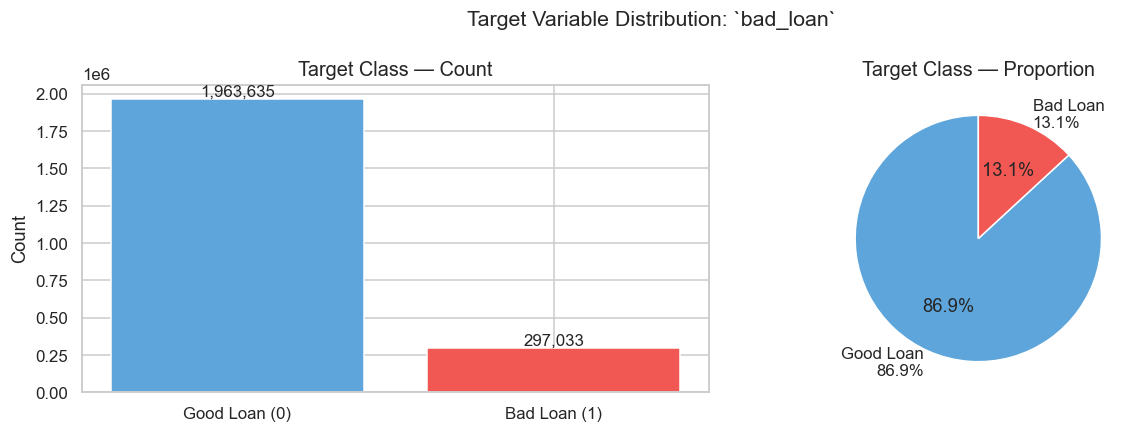

Class counts:
bad_loan
0    1963635
1     297033

Class proportions (%):
bad_loan
0    86.86
1    13.14

Imbalance ratio (majority:minority): 6.61:1

> Note: if the ratio is > 3:1, consider stratified splitting and class-weighted models.


In [30]:
# 5.1 Target Variable Distribution
target_counts = df[TARGET].value_counts().sort_index()
target_pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
labels = ['Good Loan (0)', 'Bad Loan (1)']
colors = ['#5DA5DA', '#F15854']
bars = axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Target Class — Count')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)

# Pie
axes[1].pie(
    target_pcts.values,
    labels=[f'Good Loan\n{target_pcts.iloc[0]:.1f}%', f'Bad Loan\n{target_pcts.iloc[1]:.1f}%'],
    colors=colors, autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Target Class — Proportion')

plt.suptitle(f'Target Variable Distribution: `{TARGET}`', fontsize=14)
plt.tight_layout()
plt.show()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'Class counts:\n{target_counts.to_string()}')
print(f'\nClass proportions (%):\n{target_pcts.round(2).to_string()}')
print(f'\nImbalance ratio (majority:minority): {imbalance_ratio:.2f}:1')
print('\n> Note: if the ratio is > 3:1, consider stratified splitting and class-weighted models.')


### 5.2 Univariate Analysis: Numeric Features

Examine descriptive statistics and distributions for all numeric features. High skewness (|skew| > 2) flags candidates for log-transformation during feature engineering. Kurtosis > 3 suggests heavy tails and potential outlier sensitivity.


In [31]:
# 5.2a Descriptive statistics for numeric features
num_stats = (
    df[num_features]
    .describe(percentiles=[.05, .25, .5, .75, .95])
    .T
)
num_stats['skew']     = df[num_features].skew()
num_stats['kurt']     = df[num_features].kurtosis()
num_stats['missing%'] = (df[num_features].isna().mean() * 100).round(2)

display_cols = ['count', 'mean', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'skew', 'kurt', 'missing%']
print(f'Numeric features: {len(num_features)}  — sorted by |skew|')
display(num_stats[display_cols].sort_values('skew', key=abs, ascending=False).head(30))


Numeric features: 80  — sorted by |skew|


,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,kurt,missing%
tot_coll_amt,2190392.0,232.731739,8518.461819,0.0,0.0,0.0,0.0,0.0,786.0,9152545.0,852.010132,803765.246115,3.11
annual_inc,2260664.0,77992.428687,112696.199574,0.0,27600.0,46000.0,65000.0,93000.0,160000.0,110000000.0,493.886088,439001.658861,0.00
delinq_amnt,2260639.0,12.369828,726.464781,0.0,0.0,0.0,0.0,0.0,0.0,249925.0,102.654774,16006.0037,0.00
num_tl_120dpd_2m,2107011.0,0.000637,0.027106,0.0,0.0,0.0,0.0,0.0,0.0,7.0,55.809847,5541.593233,6.80
total_rev_hi_lim,2190392.0,34573.942769,36728.495448,0.0,6000.0,14700.0,25400.0,43200.0,91100.0,9999999.0,32.557427,7520.926598,3.11
tax_liens,2260563.0,0.046771,0.377534,0.0,0.0,0.0,0.0,0.0,0.0,85.0,32.070911,3476.326736,0.00
dti,2258957.0,18.824196,14.183329,-1.0,4.94,11.89,17.84,24.49,33.88,999.0,29.201854,1755.261278,0.08
acc_now_delinq,2260639.0,0.004148,0.069617,0.0,0.0,0.0,0.0,0.0,0.0,14.0,22.907978,1256.702032,0.00
num_tl_30dpd,2190392.0,0.002814,0.056165,0.0,0.0,0.0,0.0,0.0,0.0,4.0,22.517463,622.43096,3.11
total_rec_late_fee,2260668.0,1.462469,11.502095,-0.0,0.0,0.0,0.0,0.0,0.0,1427.25,21.845867,953.985524,0.00


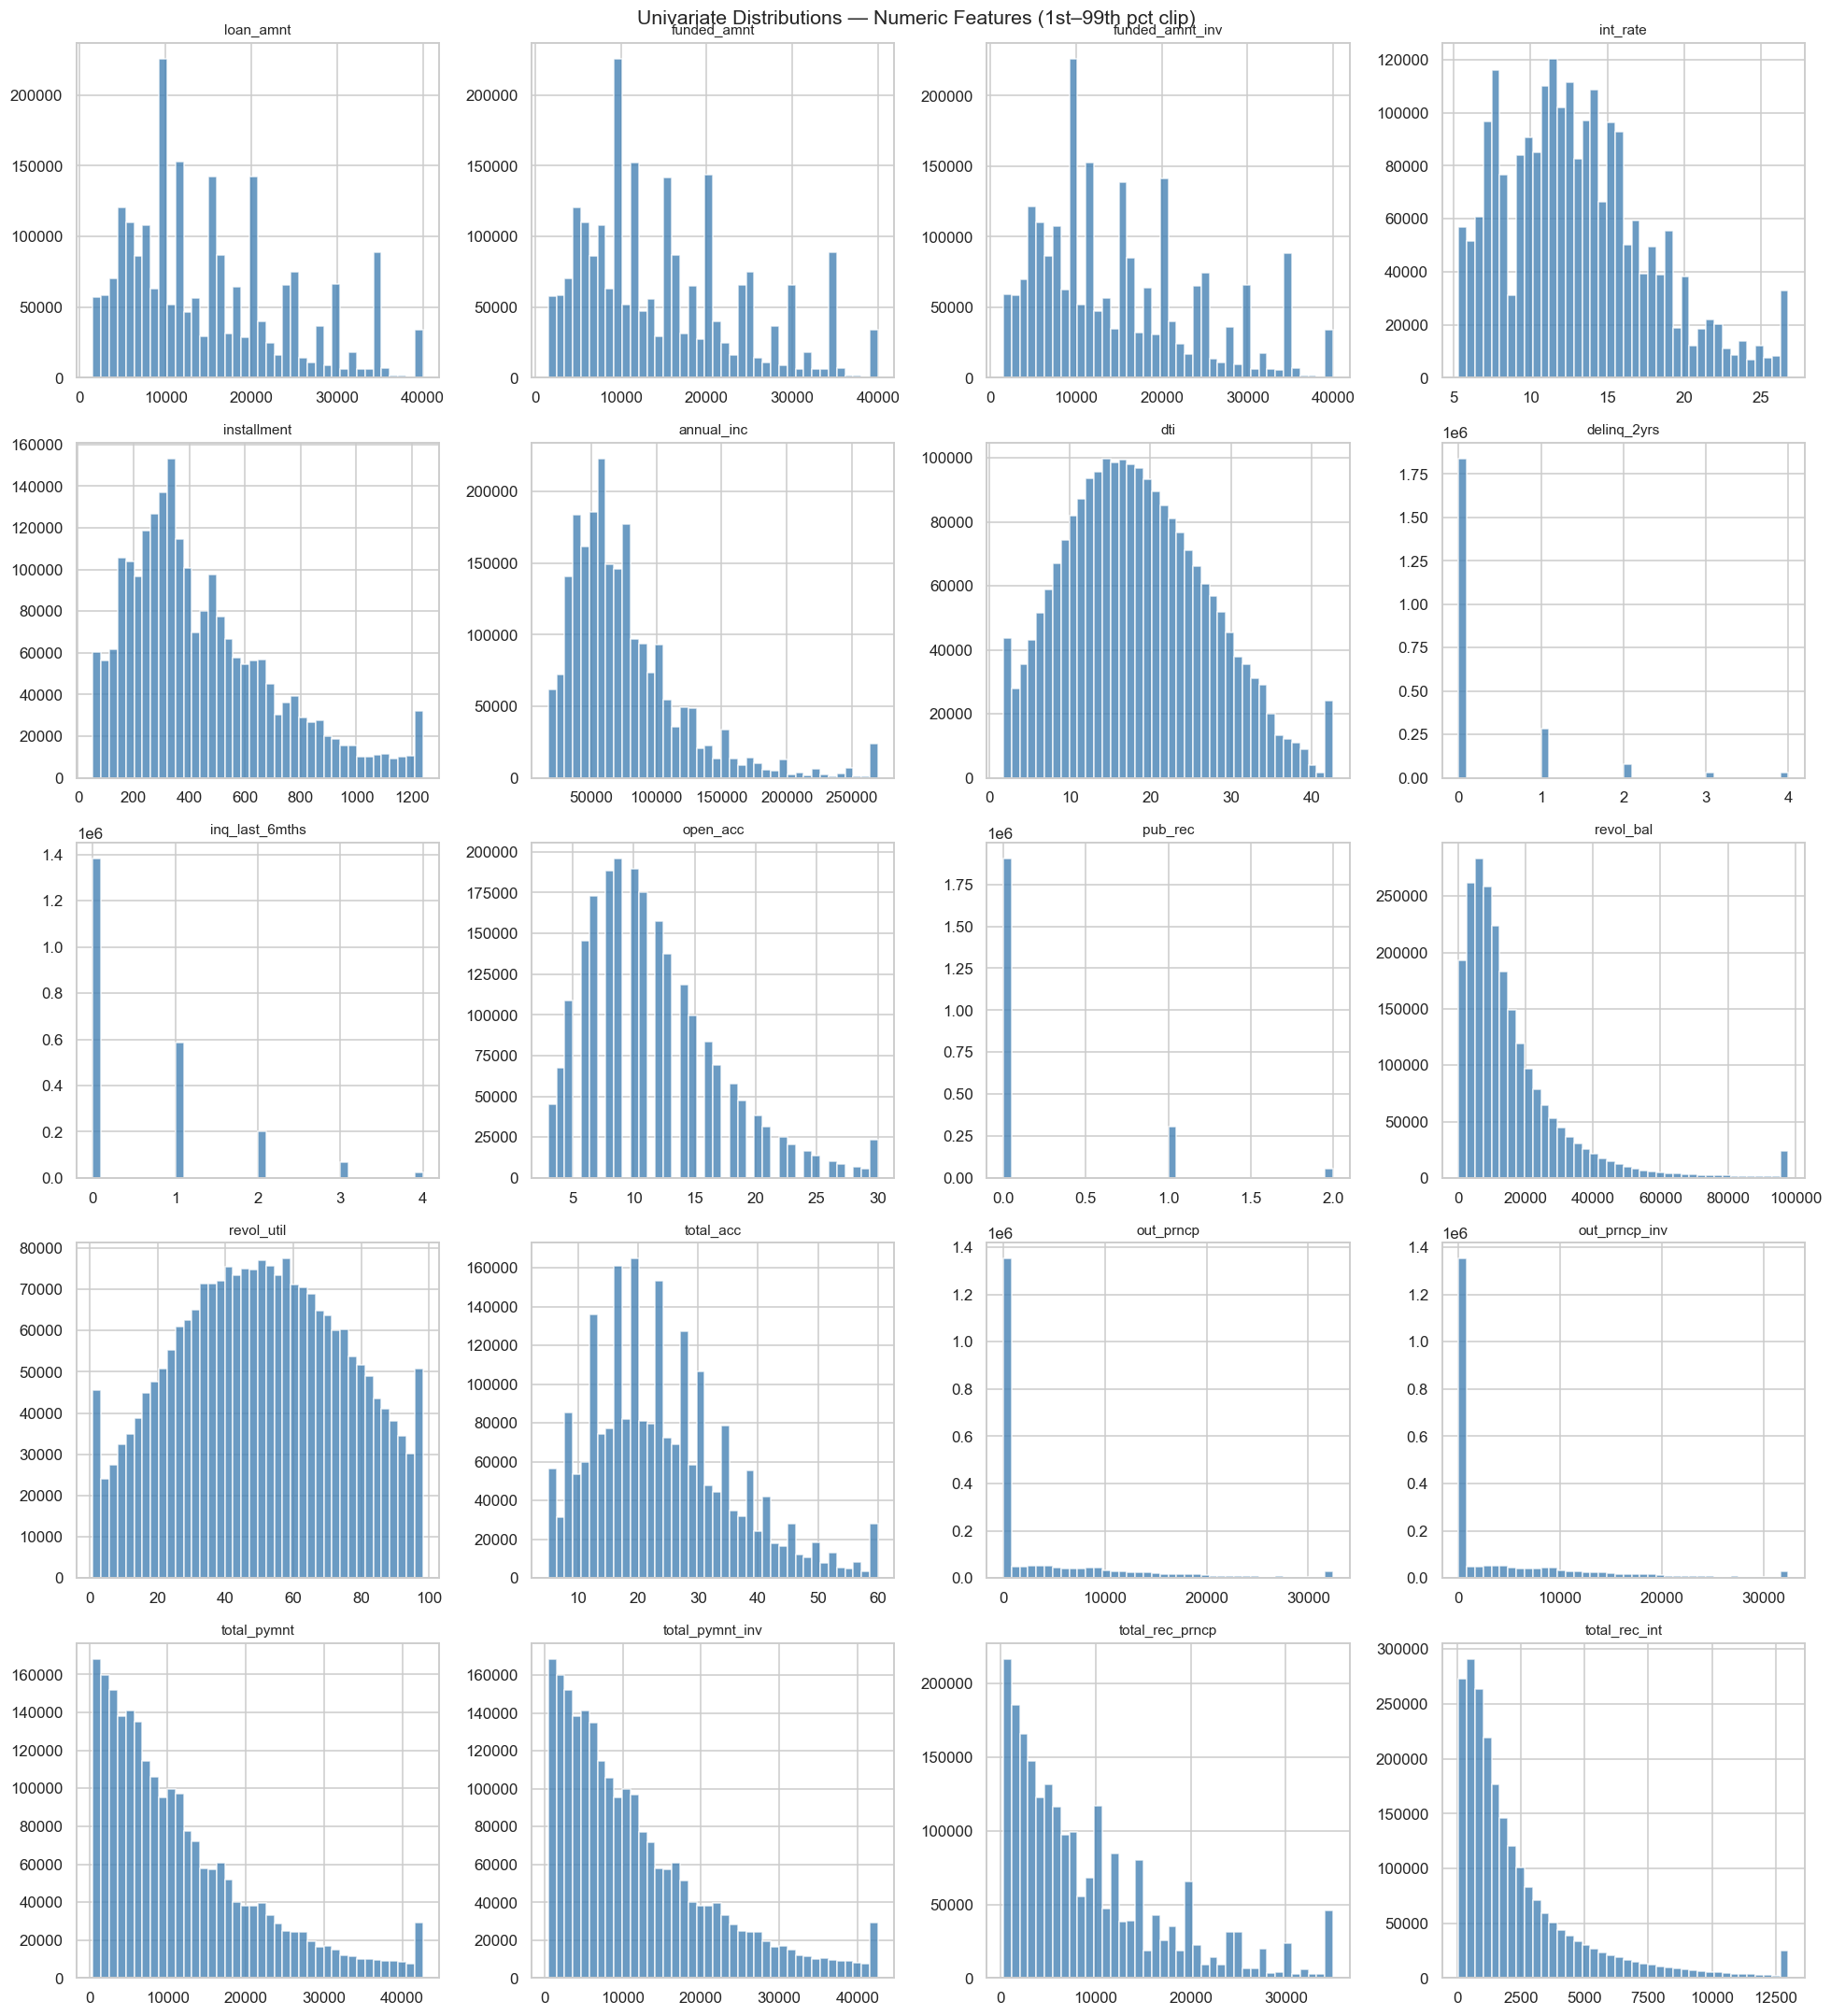


Highly skewed features (|skew| > 2): 9


,feature,abs_skew
0,annual_inc,493.886088
1,dti,29.201854
2,revol_bal,13.231988
3,pub_rec,11.376808
4,delinq_2yrs,5.929811
5,total_rec_int,2.565760
6,inq_last_6mths,2.066187
7,out_prncp_inv,2.011121
8,out_prncp,2.010716


In [32]:
# 5.2b Histogram grid for top numeric features
plot_candidates = [
    c for c in num_features
    if df[c].nunique() > 5 and df[c].notna().mean() >= 0.3
]
plot_numeric = plot_candidates[:20]

# Used in later sections (5.5) — store top 8 by data coverage
top_numeric = sorted(plot_candidates[:8], key=lambda c: df[c].notna().sum(), reverse=True)

n_cols = 4
n_rows = -(-len(plot_numeric) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_numeric):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — Numeric Features (1st–99th pct clip)', fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly skewed features
skew_series = df[plot_numeric].skew().abs().sort_values(ascending=False)
high_skew = skew_series[skew_series > 2]
print(f'\nHighly skewed features (|skew| > 2): {len(high_skew)}')
display(high_skew.reset_index().rename(columns={'index': 'feature', 0: 'abs_skew'}))


### 5.3 Univariate Analysis: Categorical Features

Examine value distributions for categorical features. Low-cardinality fields are plotted as bar charts; high-cardinality fields are summarised in a table showing top value frequency.


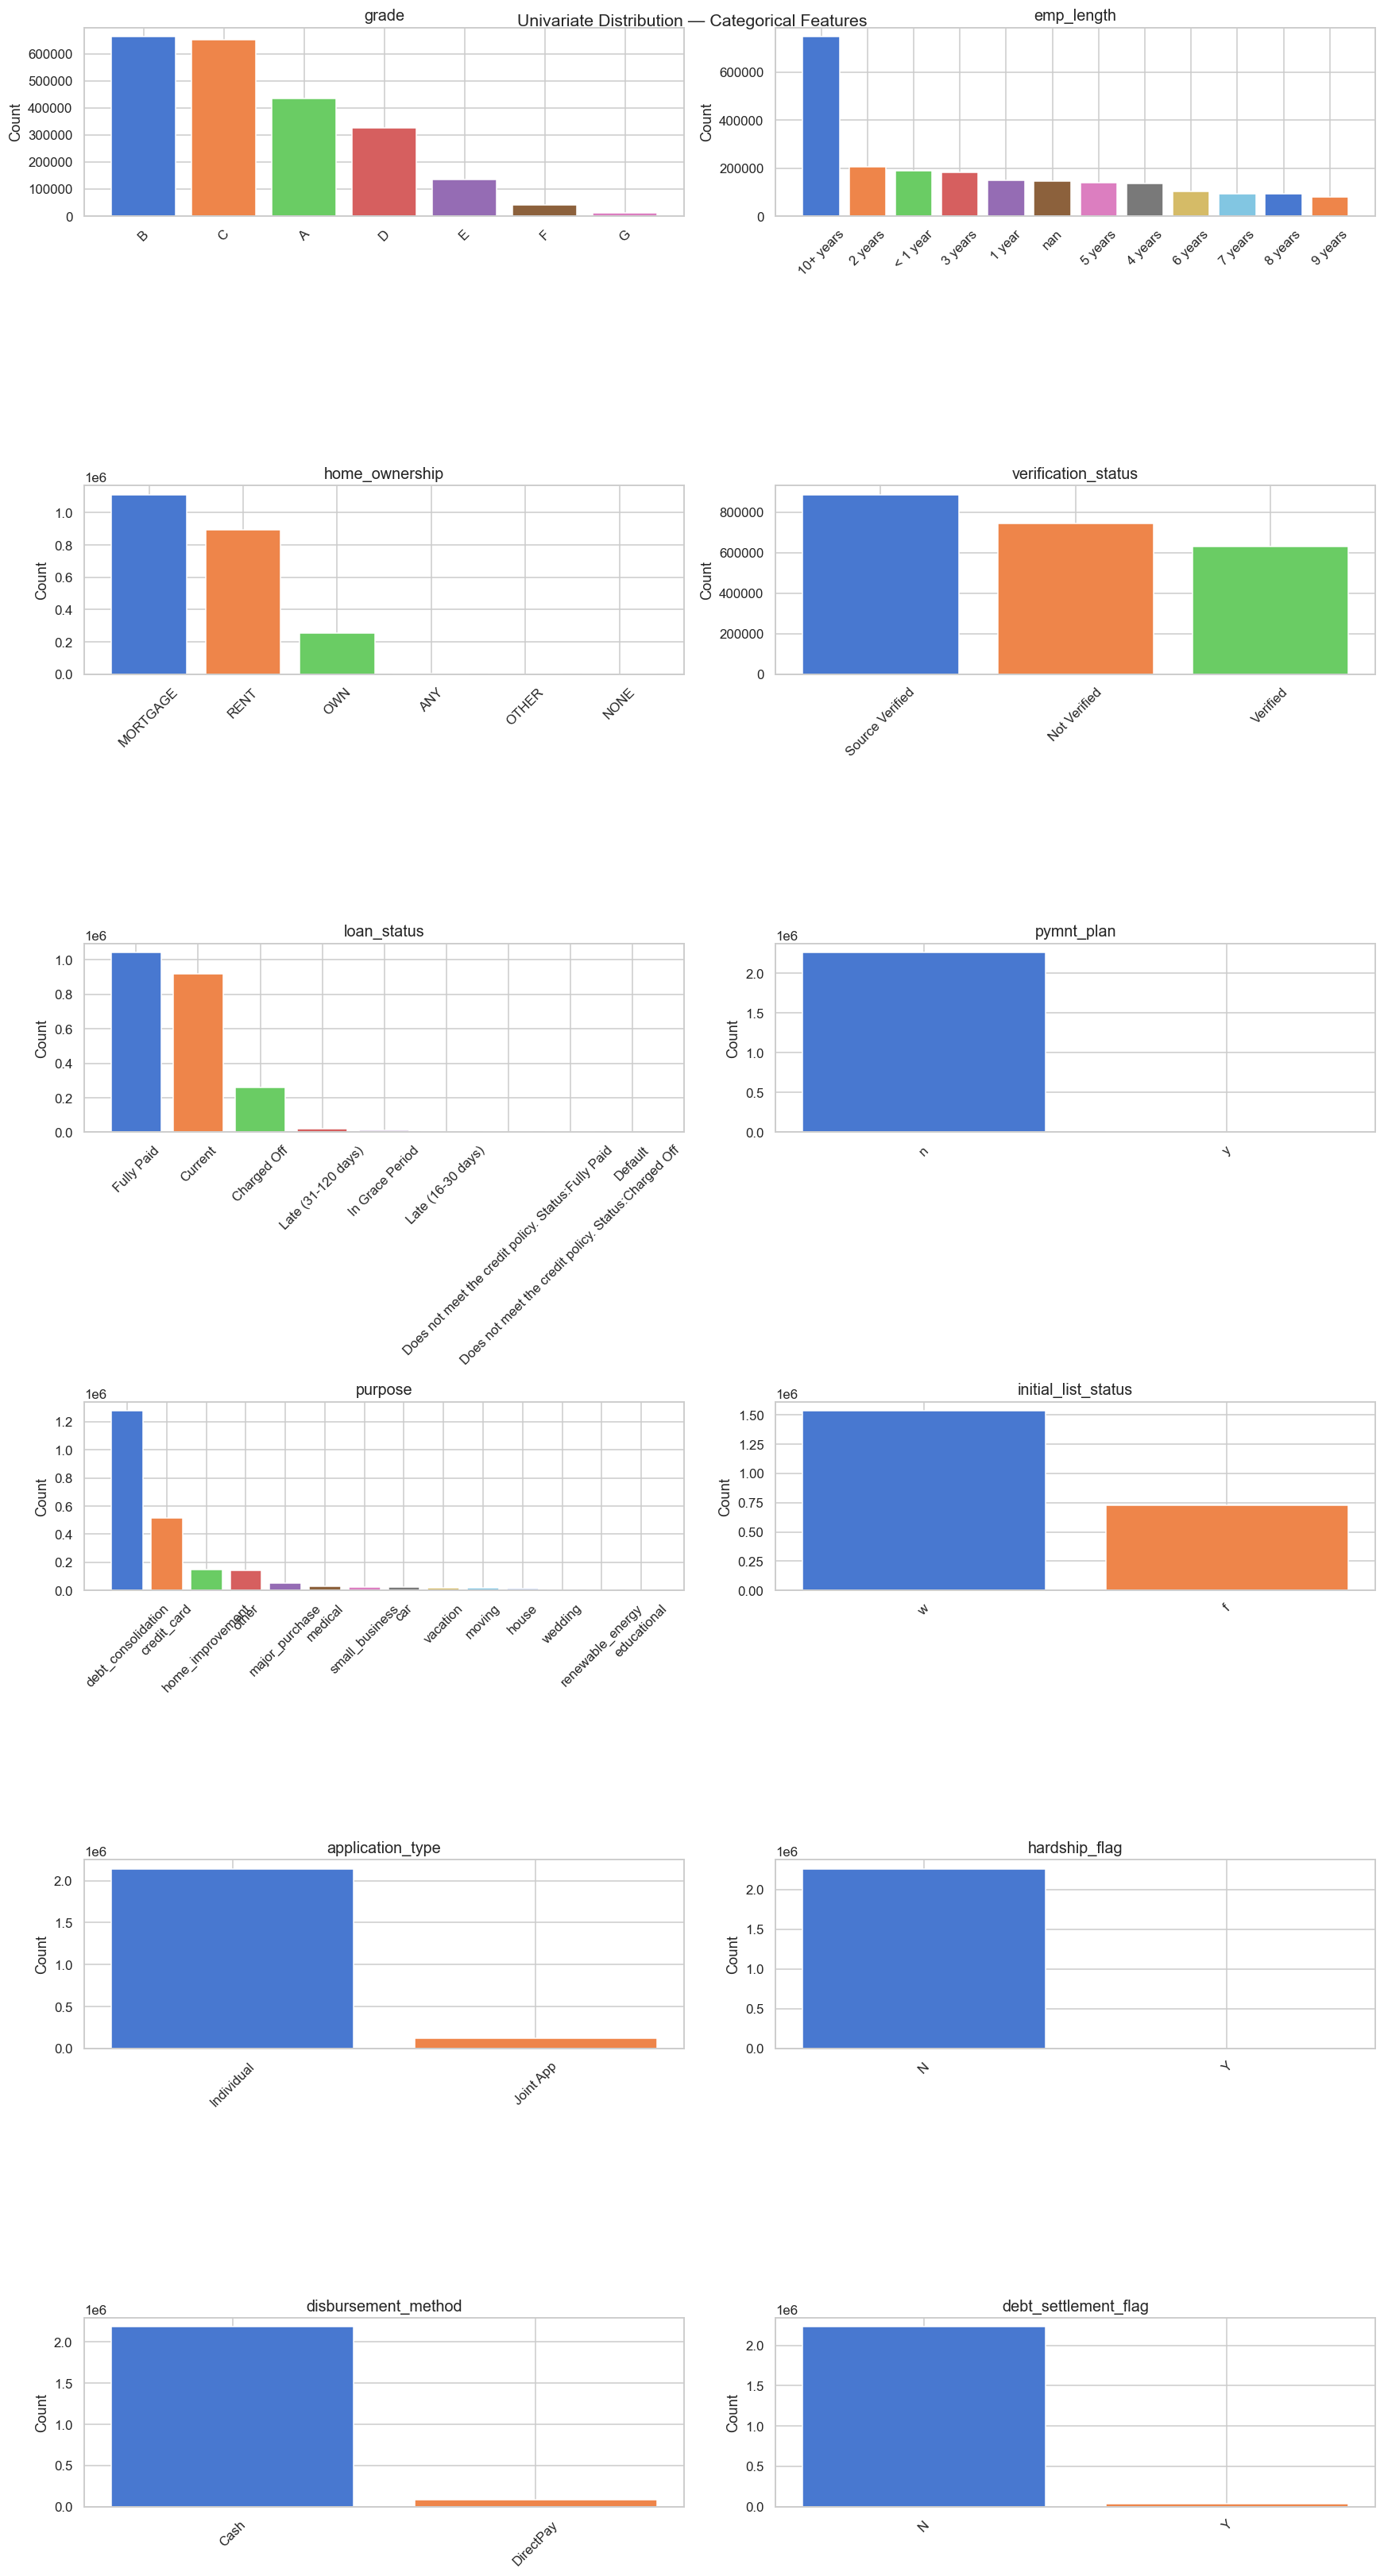


Categorical feature summary:


,feature,n_unique,top_value,top_freq_pct
6,pymnt_plan,2,n,99.97
8,initial_list_status,2,w,67.92
9,application_type,2,Individual,94.66
10,hardship_flag,2,N,99.96
11,disbursement_method,2,Cash,96.54
12,debt_settlement_flag,2,N,98.54
4,verification_status,3,Source Verified,39.20
3,home_ownership,6,MORTGAGE,49.16
0,grade,7,B,29.35
5,loan_status,9,Fully Paid,46.09


In [33]:
# 5.3 Univariate Categorical — value counts and bar charts
low_card_cats = [c for c in cat_features if df[c].nunique() <= 15]

if low_card_cats:
    n_cols = 2
    n_rows = -(-len(low_card_cats) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(low_card_cats):
        counts = df[col].value_counts(dropna=False).sort_values(ascending=False)
        axes[i].bar(counts.index.astype(str), counts.values,
                    color=sns.color_palette('muted', len(counts)))
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Univariate Distribution — Categorical Features', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No low-cardinality categorical features found after column dropping.')

# Summary table
print('\nCategorical feature summary:')
display(pd.DataFrame({
    'feature':      cat_features,
    'n_unique':     [df[c].nunique(dropna=False) for c in cat_features],
    'top_value':    [df[c].mode().iloc[0] if not df[c].mode().empty else None for c in cat_features],
    'top_freq_pct': [(df[c].value_counts(normalize=True).iloc[0] * 100).round(2)
                     if df[c].notna().any() else None for c in cat_features],
}).sort_values('n_unique'))


### 5.4 Bivariate Analysis

Expand beyond raw pairwise scatter plots by combining visual overlap checks with segmented bad-loan-rate summaries. This makes it easier to see whether higher risk concentrates inside specific value bands or feature interactions, not just whether the two classes look visually separable.

Bad-loan rate by numeric value band:


,feature,band,loan_count,bad_loan_rate
0,DTI Quintile,"(-1.001, 10.56]",452438,0.1025
1,DTI Quintile,"(10.56, 15.5]",451844,0.114
2,DTI Quintile,"(15.5, 20.28]",451903,0.1288
3,DTI Quintile,"(20.28, 26.19]",451526,0.1462
4,DTI Quintile,"(26.19, 999.0]",451246,0.1659


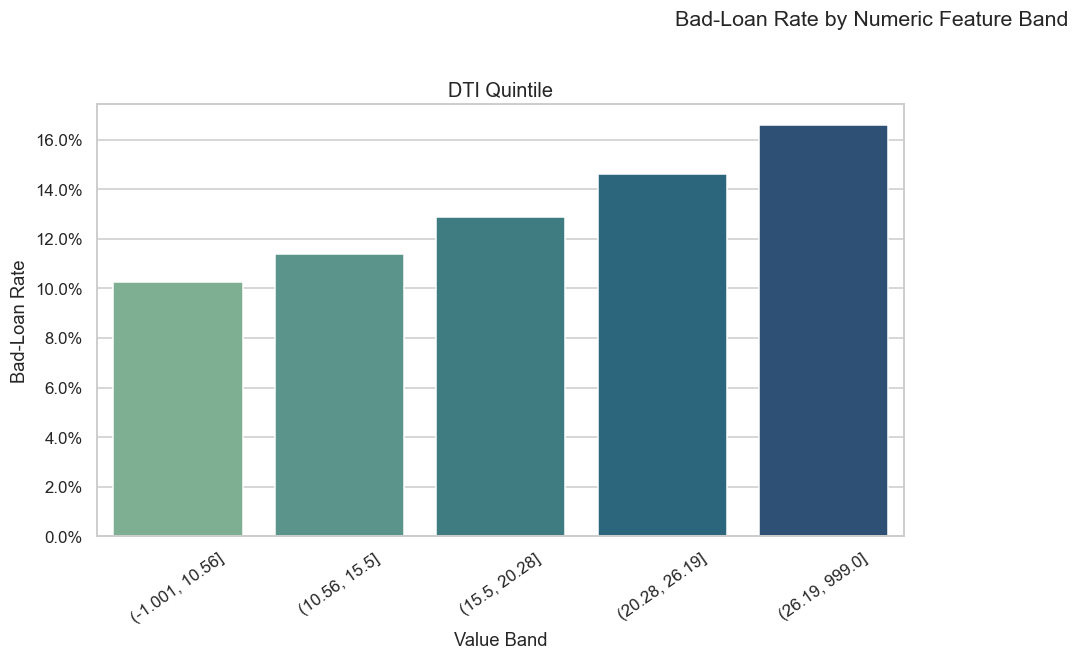

In [42]:
# 5.4 Expanded bivariate analysis — visual overlap, segmented rates, and a risk heatmap
plot_palette = {'0': '#5DA5DA', '1': '#F15854'}
class_labels = {'0': 'Good Loan', '1': 'Bad Loan'}

# 5.4a Scatter plots for a few important numeric pairs
bivariate_pairs = [
    ('loanAmnt', 'annualInc'),
    ('intRate', 'dti'),
    ('revolUtil', 'ficoRangeLow'),
]
valid_pairs = [(a, b) for a, b in bivariate_pairs if a in df.columns and b in df.columns]

if valid_pairs:
    fig, axes = plt.subplots(1, len(valid_pairs), figsize=(6 * len(valid_pairs), 5))
    if len(valid_pairs) == 1:
        axes = [axes]

    for ax, (x_col, y_col) in zip(axes, valid_pairs):
        plot_df = df[[x_col, y_col, TARGET]].dropna().copy()
        plot_df[TARGET] = plot_df[TARGET].astype(int).astype(str)
        sample_n = min(3000, len(plot_df))
        if sample_n == 0:
            ax.set_visible(False)
            continue
        plot_df = plot_df.sample(sample_n, random_state=42)

        sns.scatterplot(
            data=plot_df,
            x=x_col, y=y_col,
            hue=TARGET,
            palette=plot_palette,
            alpha=0.35,
            s=18,
            linewidth=0,
            ax=ax,
        )
        ax.set_title(f'{x_col} vs {y_col}')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles=handles,
                labels=[class_labels.get(label, label) for label in labels],
                title='Bad Loan Class',
                fontsize=9,
                title_fontsize=10,
            )

    plt.suptitle('Bivariate Scatter Plots by Bad-Loan Class', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# 5.4b Pairplot for a compact multivariate view
pairplot_cols = [
    c for c in ['loanAmnt', 'intRate', 'dti', 'revolUtil', 'ficoRangeLow', TARGET]
    if c in df.columns
]

if len(pairplot_cols) >= 4:
    sample_pp = df[pairplot_cols].dropna().copy()
    sample_n = min(1200, len(sample_pp))
    if sample_n > 0:
        sample_pp = sample_pp.sample(sample_n, random_state=42)
        sample_pp[TARGET] = sample_pp[TARGET].astype(int).astype(str)

        g = sns.pairplot(
            sample_pp,
            hue=TARGET,
            diag_kind='hist',
            plot_kws={'alpha': 0.3, 's': 12},
            palette=plot_palette,
        )
        g.figure.suptitle('Pairplot of Key Features by Bad-Loan Class', y=1.02, fontsize=13)
        plt.show()

# 5.4c Bad-loan rate by value band for high-signal numeric fields
rate_bin_specs = [
    ('intRate', 'Interest Rate Quintile'),
    ('ficoRangeLow', 'FICO Quintile'),
    ('dti', 'DTI Quintile'),
    ('loanAmnt', 'Loan Amount Quintile'),
]
rate_tables = []

for col, label in rate_bin_specs:
    if col not in df.columns:
        continue

    band_df = df[[col, TARGET]].dropna().copy()
    unique_values = band_df[col].nunique()
    if len(band_df) < 25 or unique_values < 2:
        continue

    q = min(5, unique_values)
    try:
        band_df['band'] = pd.qcut(band_df[col], q=q, duplicates='drop')
    except ValueError:
        continue

    summary = (
        band_df.groupby('band', observed=False)[TARGET]
        .agg(bad_loan_rate='mean', loan_count='size')
        .reset_index()
    )
    summary['feature'] = label
    rate_tables.append(summary[['feature', 'band', 'loan_count', 'bad_loan_rate']])

if rate_tables:
    rate_summary = pd.concat(rate_tables, ignore_index=True)
    rate_summary['bad_loan_rate'] = rate_summary['bad_loan_rate'].round(4)
    print('Bad-loan rate by numeric value band:')
    display(rate_summary)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    feature_order = rate_summary['feature'].drop_duplicates().tolist()
    for ax, feature_name in zip(axes, feature_order):
        plot_df = rate_summary.loc[rate_summary['feature'] == feature_name].copy()
        plot_df['band'] = plot_df['band'].astype(str)
        sns.barplot(
            data=plot_df,
            x='band',
            y='bad_loan_rate',
            hue='band',
            palette='crest',
            dodge=False,
            legend=False,
            ax=ax,
        )
        ax.set_title(feature_name)
        ax.set_xlabel('Value Band')
        ax.set_ylabel('Bad-Loan Rate')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.tick_params(axis='x', rotation=35)

    for ax in axes[len(feature_order):]:
        ax.set_visible(False)

    plt.suptitle('Bad-Loan Rate by Numeric Feature Band', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# 5.4d Two-way risk surface: pricing versus credit quality
if {'intRate', 'ficoRangeLow', TARGET}.issubset(df.columns):
    heatmap_df = df[['intRate', 'ficoRangeLow', TARGET]].dropna().copy()
    int_unique = heatmap_df['intRate'].nunique()
    fico_unique = heatmap_df['ficoRangeLow'].nunique()

    if len(heatmap_df) >= 50 and int_unique >= 2 and fico_unique >= 2:
        int_q = min(6, int_unique)
        fico_q = min(6, fico_unique)
        heatmap_df['int_rate_band'] = pd.qcut(heatmap_df['intRate'], q=int_q, duplicates='drop')
        heatmap_df['fico_band'] = pd.qcut(heatmap_df['ficoRangeLow'], q=fico_q, duplicates='drop')

        risk_surface = heatmap_df.pivot_table(
            index='int_rate_band',
            columns='fico_band',
            values=TARGET,
            aggfunc='mean',
            observed=False,
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(
            risk_surface,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.4,
            cbar_kws={'label': 'Bad-Loan Rate'},
            ax=ax,
        )
        ax.set_title('Bad-Loan Rate Heatmap: Interest Rate vs FICO Band')
        ax.set_xlabel('FICO Range Low Band')
        ax.set_ylabel('Interest Rate Band')
        plt.tight_layout()
        plt.show()

### 5.5 Features Compared to Target Variable

Compare numeric feature distributions across the two bad-loan classes using boxplots and a mean-difference table. Features with large group-level differences are strong candidate predictors.


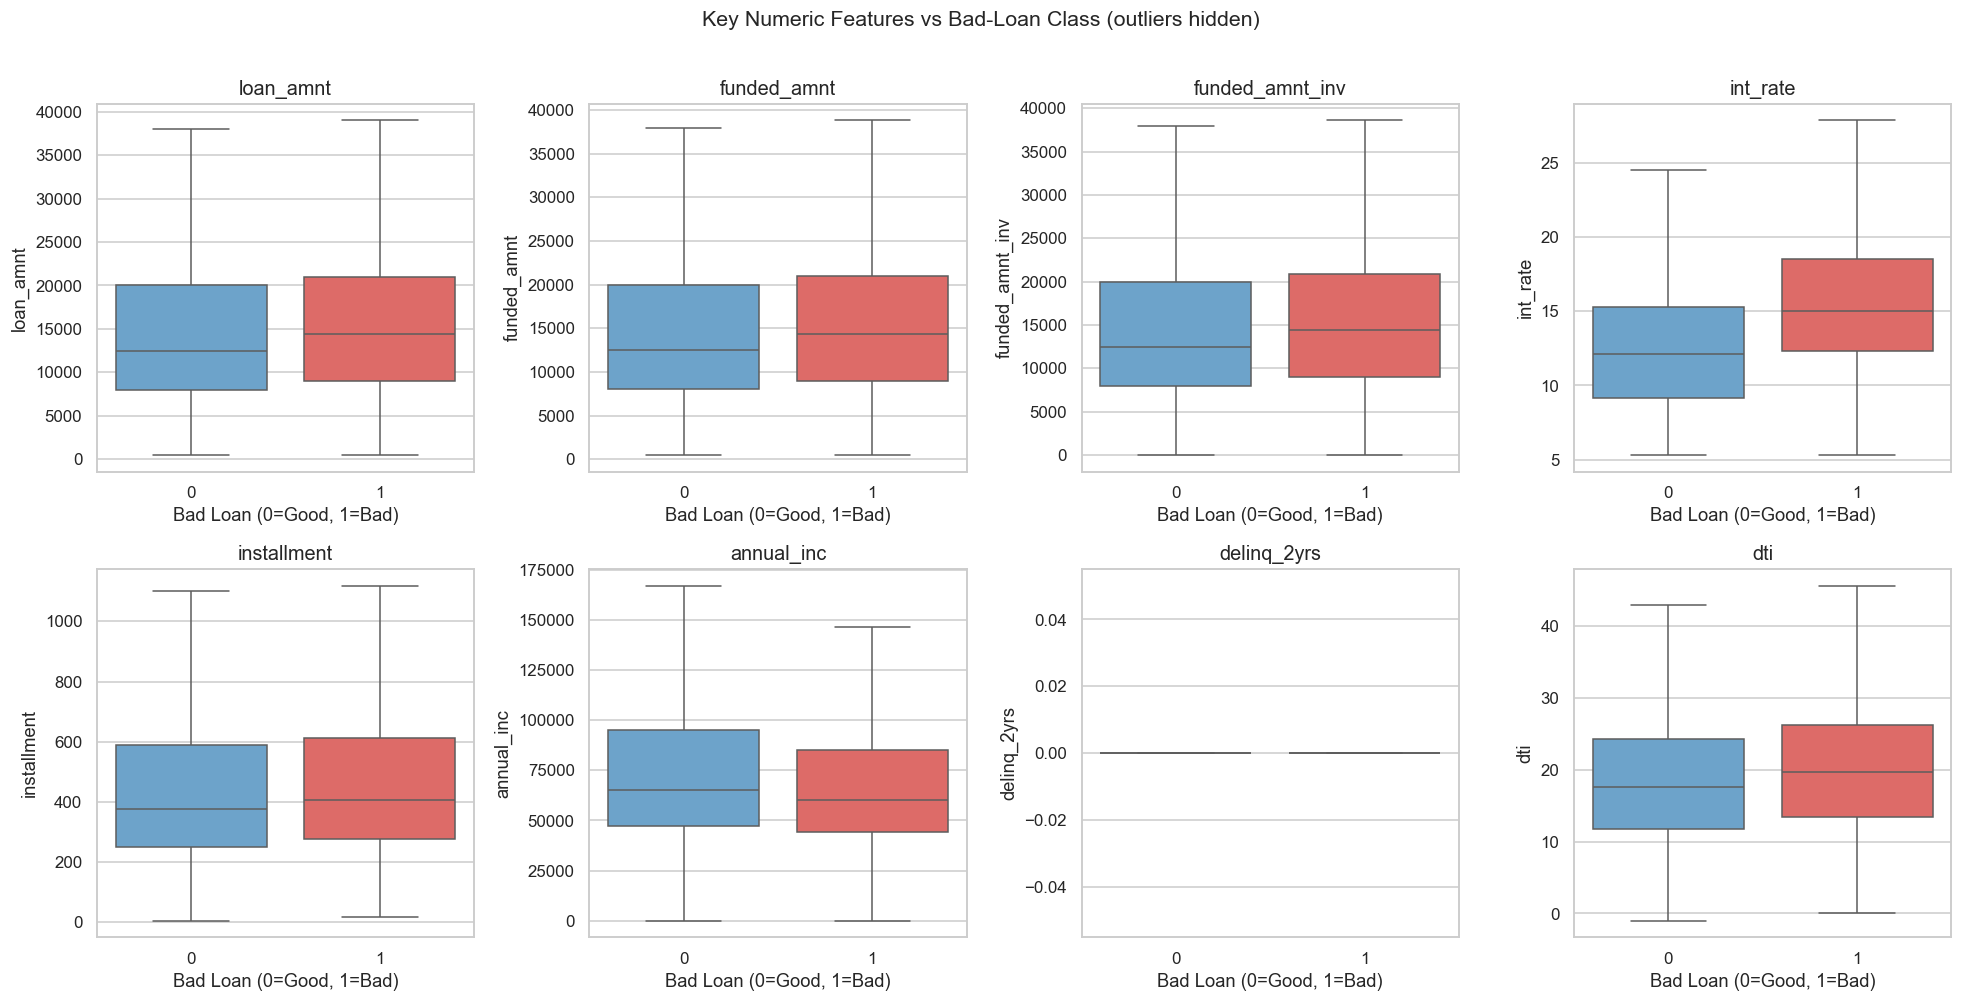

In [37]:
# 5.5a Boxplots — top numeric features by bad-loan class
n_plot = min(8, len(top_numeric))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
plot_palette = {'0': '#5DA5DA', '1': '#F15854'}

for i, col in enumerate(top_numeric[:n_plot]):
    plot_df = df.loc[df[col].notna(), [TARGET, col]].copy()
    plot_df[TARGET] = plot_df[TARGET].astype(str)
    sns.boxplot(
        data=plot_df,
        x=TARGET, y=col, hue=TARGET,
        palette=plot_palette,
        dodge=False,
        legend=False,
        showfliers=False,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Bad Loan (0=Good, 1=Bad)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numeric Features vs Bad-Loan Class (outliers hidden)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [38]:
# 5.5b Mean feature values by bad-loan class
mean_by_target = df.groupby(TARGET)[top_numeric].mean().T
mean_by_target.columns = ['Good Loan (0)', 'Bad Loan (1)']
mean_by_target['Abs % Diff'] = (
    (mean_by_target['Bad Loan (1)'] - mean_by_target['Good Loan (0)'])
    / mean_by_target['Good Loan (0)'].replace(0, np.nan)
    * 100
).abs().round(2)

print('Mean feature values by bad-loan class — sorted by absolute % difference:')
display(mean_by_target.sort_values('Abs % Diff', ascending=False))


Mean feature values by bad-loan class — sorted by absolute % difference:


,Good Loan (0),Bad Loan (1),Abs % Diff
int_rate,12.699803,15.691700,23.56
delinq_2yrs,0.299598,0.355015,18.50
annual_inc,79017.324810,71217.027304,9.87
dti,18.624910,20.141029,8.14
installment,442.344381,468.702706,5.96
loan_amnt,14947.793875,15702.311528,5.05
funded_amnt,14942.931655,15694.367293,5.03
funded_amnt_inv,14926.880436,15661.760887,4.92


### 5.6 Correlation Matrix

Compute pairwise Pearson correlations across numeric features. Focus on the top features correlated with `bad_loan` to guide feature selection, and flag pairs with very high mutual correlation as potential multicollinearity candidates for linear models.


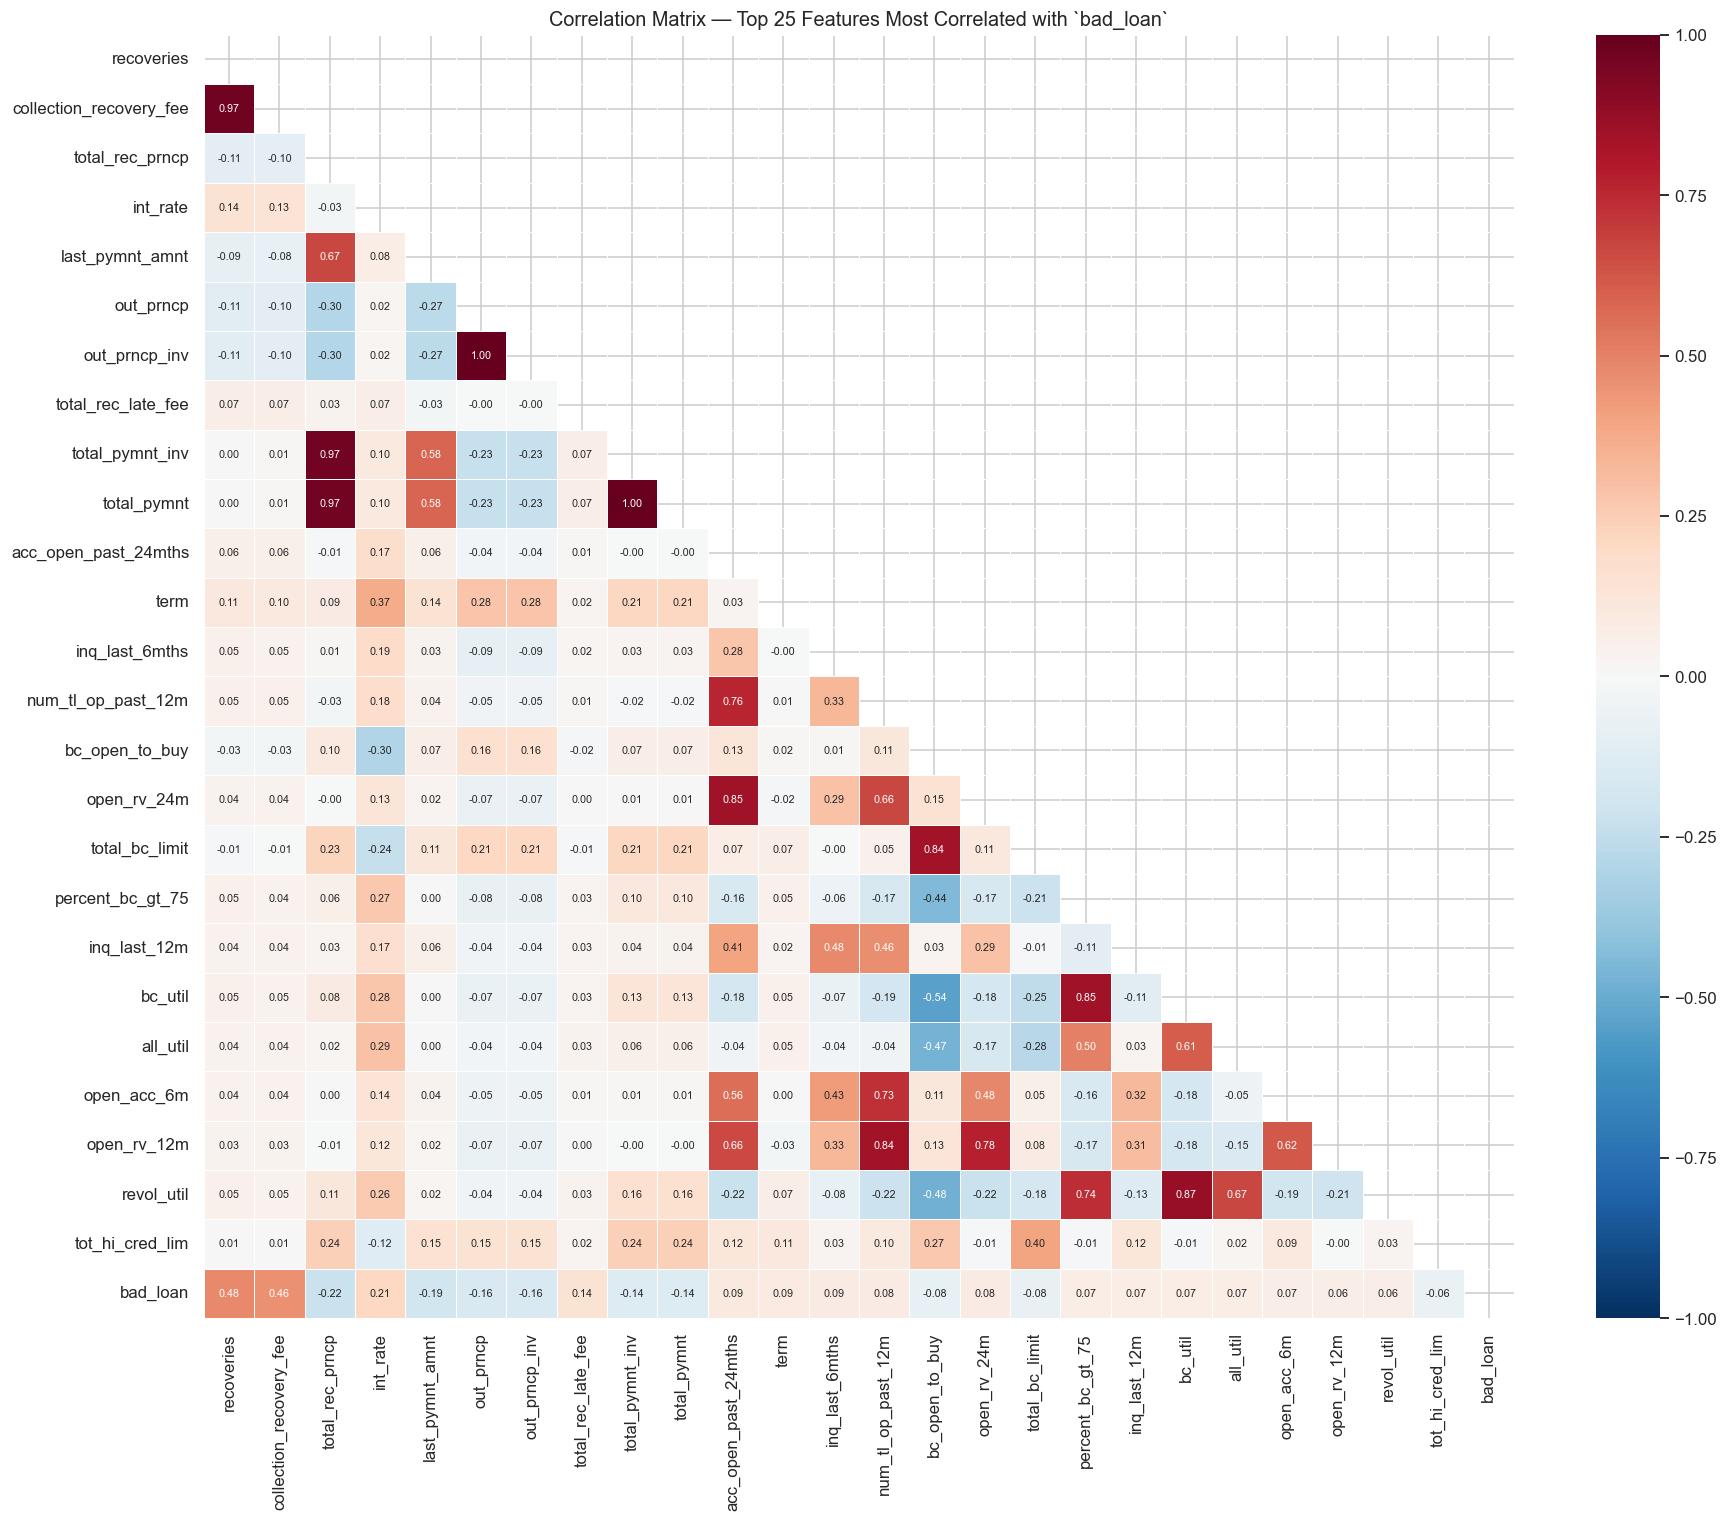


Top 15 features by |correlation| with `bad_loan`:


,feature,abs_corr_with_bad_loan
0,recoveries,0.482023
1,collection_recovery_fee,0.457007
2,total_rec_prncp,0.223022
3,int_rate,0.209173
4,last_pymnt_amnt,0.187750
5,out_prncp,0.162198
6,out_prncp_inv,0.162182
7,total_rec_late_fee,0.143870
8,total_pymnt_inv,0.137199
9,total_pymnt,0.137170


In [39]:
# 5.6 Correlation Matrix
# Use numeric features with sufficient data coverage
corr_candidates = [c for c in num_features if df[c].notna().mean() >= 0.5]
corr_df = df[corr_candidates + [TARGET]].corr()

# Rank features by absolute correlation with target, take top 25
target_corr = corr_df[TARGET].drop(TARGET).abs().sort_values(ascending=False)
top25 = target_corr.head(25).index.tolist()
plot_corr = df[top25 + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(17, 14))
mask = np.triu(np.ones_like(plot_corr, dtype=bool))
sns.heatmap(
    plot_corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title(f'Correlation Matrix — Top 25 Features Most Correlated with `{TARGET}`', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nTop 15 features by |correlation| with `{TARGET}`:')
display(
    target_corr.head(15)
    .reset_index()
    .rename(columns={'index': 'feature', TARGET: 'abs_corr_with_bad_loan'})
)


### 5.7 Additional EDA: Bad-Loan Rates by Category and Loan Characteristics

Examine how bad-loan rates vary across loan grade, purpose, and other categorical splits. Also inspect the relationship between interest rate and FICO score as a data quality and risk-pricing check.


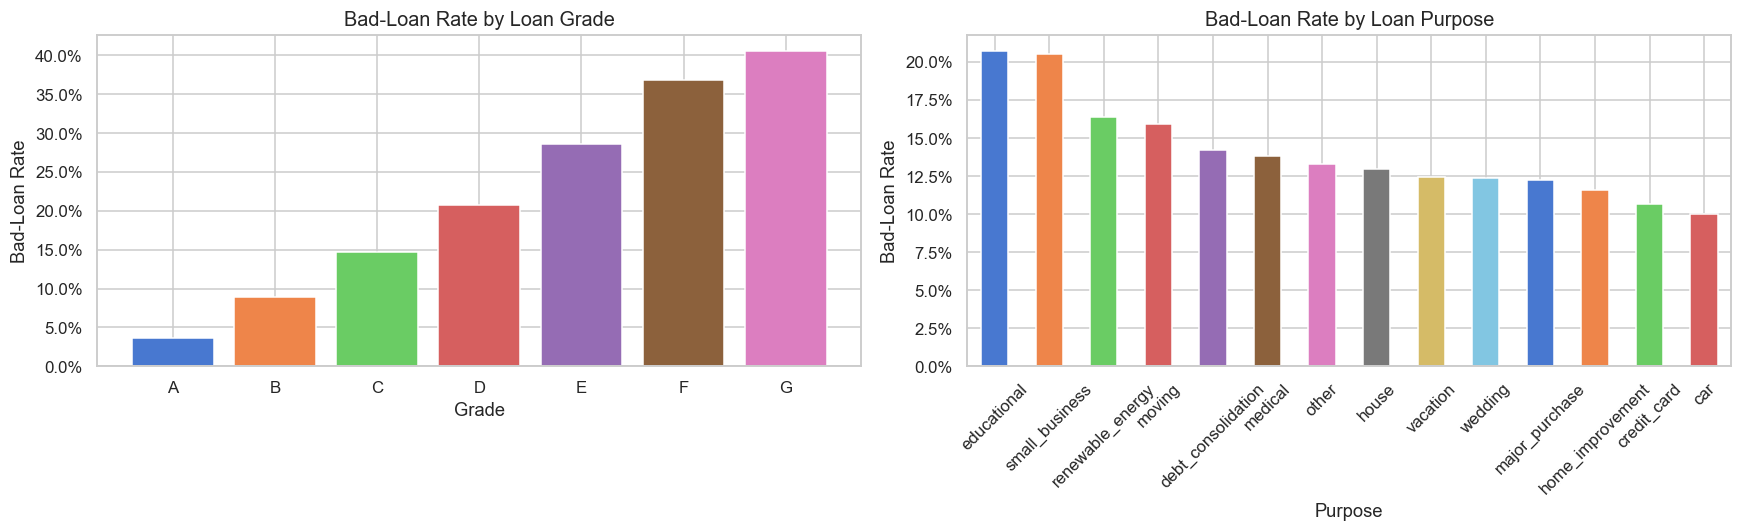

In [40]:
# 5.7 Additional EDA: Bad-loan rate by grade and purpose
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'grade' in df.columns:
    grade_default = df.groupby('grade')[TARGET].mean().sort_index()
    axes[0].bar(grade_default.index, grade_default.values,
                color=sns.color_palette('muted', len(grade_default)))
    axes[0].set_title('Bad-Loan Rate by Loan Grade')
    axes[0].set_xlabel('Grade')
    axes[0].set_ylabel('Bad-Loan Rate')
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

if 'purpose' in df.columns:
    purpose_default = df.groupby('purpose')[TARGET].mean().sort_values(ascending=False)
    purpose_default.plot(kind='bar', ax=axes[1],
                         color=sns.color_palette('muted', len(purpose_default)))
    axes[1].set_title('Bad-Loan Rate by Loan Purpose')
    axes[1].set_xlabel('Purpose')
    axes[1].set_ylabel('Bad-Loan Rate')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Loan amount distribution by grade
if 'loanAmnt' in df.columns and 'grade' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    grade_order = sorted(df['grade'].dropna().unique())
    sns.boxplot(data=df, x='grade', y='loanAmnt', hue='grade', order=grade_order, palette='muted', dodge=False, legend=False, ax=ax)
    ax.set_title('Loan Amount Distribution by Grade')
    ax.set_xlabel('Grade')
    ax.set_ylabel('Loan Amount ($)')
    plt.tight_layout()
    plt.show()

# Interest rate vs FICO by bad-loan class
if 'intRate' in df.columns and 'ficoRangeLow' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, color in [(0, '#5DA5DA'), (1, '#F15854')]:
        sub = df[df[TARGET] == label][['intRate', 'ficoRangeLow']].dropna().sample(min(2000, len(df)), random_state=42)
        ax.scatter(sub['ficoRangeLow'], sub['intRate'], alpha=0.3, s=8, color=color,
                   label='Good Loan' if label == 0 else 'Bad Loan')
    ax.set_xlabel('FICO Range Low')
    ax.set_ylabel('Interest Rate (%)')
    ax.set_title('Interest Rate vs FICO Score by Bad-Loan Class')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# TODO: Analyze target distribution and class imbalance
# HINT: df[TARGET].value_counts(normalize=True)

# TODO: Univariate analysis for numeric features
# HINT: hist(), boxplot(), describe()

# TODO: Univariate analysis for categorical features
# HINT: value_counts(), seaborn.countplot

# TODO: Compare features by target class
# HINT: groupby(TARGET), seaborn.boxplot/histplot

## 6. Statistical Testing

Use statistical hypothesis tests to assess whether observed group differences are likely meaningful.

Interpretation reminder:
- Define a significance level (for example, alpha = 0.05).
- Compare p-value against alpha.
- Explain practical meaning, not only statistical significance.

### 6.1 T-Tests

Compare mean values of a numeric feature between bad-loan and good-loan groups.

In [45]:
# 6.1 Welch's t-test for a key numeric predictor
from scipy.stats import ttest_ind

alpha = 0.05
feature_candidates = [
    'intRate', 'int_rate',
    'dti',
    'loanAmnt', 'loan_amnt',
    'ficoRangeLow', 'fico_range_low',
]
feature_name = next((col for col in feature_candidates if col in df.columns), None)

if feature_name is None:
    raise KeyError(
        'None of the candidate numeric features for Section 6.1 were found in the cleaned dataset.'
    )

group_bad_loan = df.loc[df[TARGET] == 1, feature_name].dropna()
group_good_loan = df.loc[df[TARGET] == 0, feature_name].dropna()

if len(group_bad_loan) < 2 or len(group_good_loan) < 2:
    raise ValueError('Both target groups need at least two non-missing observations to run a t-test.')

t_stat, p_value = ttest_ind(group_bad_loan, group_good_loan, equal_var=False)
bad_mean = group_bad_loan.mean()
good_mean = group_good_loan.mean()
mean_diff = bad_mean - good_mean

summary = pd.DataFrame({
    'group': ['Good Loan (0)', 'Bad Loan (1)'],
    'n_obs': [len(group_good_loan), len(group_bad_loan)],
    'mean': [good_mean, bad_mean],
    'std': [group_good_loan.std(), group_bad_loan.std()],
})

print(f"Selected feature for t-test: {feature_name}")
display(summary.round(4))
print(f"Welch t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6g}")
print(f"Mean difference (Bad - Good): {mean_diff:.4f}")

if p_value < alpha:
    print(
        f"Decision at alpha={alpha}: reject the null hypothesis. "
        f"The average {feature_name} differs significantly between bad and good loans."
    )
else:
    print(
        f"Decision at alpha={alpha}: fail to reject the null hypothesis. "
        f"There is not enough evidence that average {feature_name} differs between bad and good loans."
    )

print(
    f"Interpretation: bad loans have an average {feature_name} of {bad_mean:.2f}, "
    f"while good loans average {good_mean:.2f}."
 )

Selected feature for t-test: int_rate


,group,n_obs,mean,std
0,Good Loan (0),1963635,12.6998,4.6916
1,Bad Loan (1),297033,15.6917,4.9419


Welch t-statistic: 309.5284
p-value: 0
Mean difference (Bad - Good): 2.9919
Decision at alpha=0.05: reject the null hypothesis. The average int_rate differs significantly between bad and good loans.
Interpretation: bad loans have an average int_rate of 15.69, while good loans average 12.70.


### 6.2 ANOVA

Compare means across more than two groups for a numeric outcome.

In [49]:
# 6.2 One-way ANOVA for a multi-group comparison
from scipy.stats import f_oneway

alpha = 0.05
group_candidates = ['grade', 'subGrade', 'purpose', 'homeOwnership', 'home_ownership']
value_candidates = ['intRate', 'int_rate', 'loanAmnt', 'loan_amnt', 'dti']

group_col = next((col for col in group_candidates if col in df.columns), None)
value_col = next((col for col in value_candidates if col in df.columns), None)

if group_col is None or value_col is None:
    raise KeyError('Could not find suitable grouping and numeric columns for ANOVA in the cleaned dataset.')

anova_df = df[[group_col, value_col]].dropna().copy()
group_counts = anova_df[group_col].value_counts()
valid_groups = group_counts[group_counts >= 30].index.tolist()

if len(valid_groups) < 3:
    raise ValueError('ANOVA needs at least three groups with a reasonable number of observations.')

anova_df = anova_df[anova_df[group_col].isin(valid_groups)].copy()
group_order = sorted(anova_df[group_col].astype(str).unique().tolist())
group_arrays = [
    anova_df.loc[anova_df[group_col].astype(str) == group_name, value_col].dropna()
    for group_name in group_order
]

if any(len(group) < 2 for group in group_arrays):
    raise ValueError('Each ANOVA group needs at least two observations.')

f_stat, p_value = f_oneway(*group_arrays)

anova_summary = (
    anova_df.groupby(group_col, observed=False)[value_col]
    .agg(n_obs='size', mean='mean', std='std')
    .reset_index()
    .sort_values('mean', ascending=False)
 )

print(f"Selected grouping feature: {group_col}")
print(f"Selected numeric outcome: {value_col}")
display(anova_summary.round(4))
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6g}")

if p_value < alpha:
    print(
        f"Decision at alpha={alpha}: reject the null hypothesis. "
        f"At least one {group_col} group has a different average {value_col}."
    )
    print(
        'Recommended next step: run a post-hoc Tukey HSD test to identify which specific groups differ.'
    )
else:
    print(
        f"Decision at alpha={alpha}: fail to reject the null hypothesis. "
        f"There is not enough evidence that mean {value_col} differs across {group_col} groups."
    )

Selected grouping feature: grade
Selected numeric outcome: int_rate


,grade,n_obs,mean,std
6,G,12168,28.0743,2.8046
5,F,41800,25.4542,2.9282
4,E,135639,21.8298,2.7033
3,D,324424,18.1433,1.6762
2,C,650053,14.1438,1.2510
1,B,663557,10.6758,1.2383
0,A,433027,7.0846,0.9845


ANOVA F-statistic: 3756991.9199
p-value: 0
Decision at alpha=0.05: reject the null hypothesis. At least one grade group has a different average int_rate.
Recommended next step: run a post-hoc Tukey HSD test to identify which specific groups differ.


### 6.3 Chi-Square Test

Assess independence between two categorical variables.

In [50]:
# 6.3 Chi-square test of independence between a categorical feature and the target
from scipy.stats import chi2_contingency

alpha = 0.05
cat_candidates = ['grade', 'purpose', 'homeOwnership', 'home_ownership', 'term', 'isIncV']

cat_col = next((col for col in cat_candidates if col in df.columns), None)

if cat_col is None:
    raise KeyError('Could not find a suitable categorical column for the chi-square test.')

# Build contingency table and filter out any empty columns
contingency_table = pd.crosstab(df[cat_col], df[TARGET])
contingency_table = contingency_table.loc[(contingency_table.sum(axis=1) > 0), :]

if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
    raise ValueError('Contingency table must have at least two rows and two columns.')

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test: {cat_col} vs {TARGET}")
print(f"Contingency table (counts):")
display(contingency_table)

# Observed vs expected percentage divergence per cell
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns,
)
print(f"Expected frequencies (under H0):")
display(expected_df.round(1))

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6g}")

if p_value < alpha:
    print(
        f"Decision at alpha={alpha}: reject the null hypothesis. "
        f"{cat_col} and {TARGET} are NOT independent — the distribution of bad loans "
        f"differs significantly across {cat_col} categories."
    )
else:
    print(
        f"Decision at alpha={alpha}: fail to reject the null hypothesis. "
        f"There is not enough evidence that {cat_col} and {TARGET} are dependent."
    )

# Bad-loan rate per category for practical context
rate_by_cat = (
    df.groupby(cat_col, observed=False)[TARGET]
    .agg(n_obs='size', bad_loan_rate='mean')
    .reset_index()
    .sort_values('bad_loan_rate', ascending=False)
)
rate_by_cat['bad_loan_rate'] = rate_by_cat['bad_loan_rate'].round(4)
print(f"\nBad-loan rate by {cat_col}:")
display(rate_by_cat)

Chi-square test: grade vs bad_loan
Contingency table (counts):


bad_loan,0,1
grade,,
A,417002,16025
B,604799,58758
C,554473,95580
D,256999,67425
E,96758,38881
F,26380,15420
G,7224,4944


Expected frequencies (under H0):


bad_loan,0,1
grade,,
A,376130.8,56896.2
B,576371.1,87185.9
C,564641.4,85411.6
D,281797.4,42626.6
E,117817.2,17821.8
F,36307.8,5492.2
G,10569.2,1598.8


Chi-square statistic: 119842.2129
Degrees of freedom: 6
p-value: 0
Decision at alpha=0.05: reject the null hypothesis. grade and bad_loan are NOT independent — the distribution of bad loans differs significantly across grade categories.

Bad-loan rate by grade:


,grade,n_obs,bad_loan_rate
6,G,12168,0.4063
5,F,41800,0.3689
4,E,135639,0.2867
3,D,324424,0.2078
2,C,650053,0.147
1,B,663557,0.0886
0,A,433027,0.037


## 7. Feature Engineering

Create model-ready features through transformation, encoding, and scaling.

In [52]:
# 7. Feature Engineering
from sklearn.preprocessing import StandardScaler

fe_log = []  # transformation log
df_fe = df.copy()

# ── 7a. New financial ratios and derived features ────────────────────────────

# Monthly payment-to-income burden: higher ratio → more financial stress
# Handles both camelCase and snake_case column naming
installment_col = next((c for c in ['installment'] if c in df_fe.columns), None)
annual_inc_col  = next((c for c in ['annualInc', 'annual_inc'] if c in df_fe.columns), None)
loan_amnt_col   = next((c for c in ['loanAmnt', 'loan_amnt'] if c in df_fe.columns), None)
fico_low_col    = next((c for c in ['ficoRangeLow', 'fico_range_low'] if c in df_fe.columns), None)
fico_high_col   = next((c for c in ['ficoRangeHigh', 'fico_range_high'] if c in df_fe.columns), None)

if installment_col and annual_inc_col:
    monthly_inc = df_fe[annual_inc_col] / 12
    df_fe['installment_income_ratio'] = df_fe[installment_col] / monthly_inc.replace(0, np.nan)
    fe_log.append({'feature': 'installment_income_ratio', 'type': 'ratio',
                   'formula': f'{installment_col} / ({annual_inc_col} / 12)'})

if loan_amnt_col and annual_inc_col:
    df_fe['loan_to_income'] = df_fe[loan_amnt_col] / df_fe[annual_inc_col].replace(0, np.nan)
    fe_log.append({'feature': 'loan_to_income', 'type': 'ratio',
                   'formula': f'{loan_amnt_col} / {annual_inc_col}'})

if fico_low_col and fico_high_col:
    df_fe['fico_mid'] = (df_fe[fico_low_col] + df_fe[fico_high_col]) / 2
    fe_log.append({'feature': 'fico_mid', 'type': 'derived',
                   'formula': f'({fico_low_col} + {fico_high_col}) / 2'})

# Log1p transforms for right-skewed monetary and count fields
log_candidates = [
    'annualInc', 'annual_inc', 'loanAmnt', 'loan_amnt',
    'revolBal', 'revol_bal', 'fundedAmnt', 'funded_amnt',
    'installment', 'tot_cur_bal',
]
seen_log = set()
for col in log_candidates:
    if col in df_fe.columns and col not in seen_log and df_fe[col].notna().sum() > 0:
        if df_fe[col].dropna().min() >= 0:
            new_col = f'log1p_{col}'
            df_fe[new_col] = np.log1p(df_fe[col])
            fe_log.append({'feature': new_col, 'type': 'log1p',
                           'formula': f'log1p({col})'})
            seen_log.add(col)

print(f'New engineered features added: {len(fe_log)}')

# ── 7b. Select columns for modeling ─────────────────────────────────────────

# Numerics with at least 30 % coverage
numeric_fe_cols = [
    c for c in df_fe.select_dtypes(include=[np.number]).columns
    if c != TARGET and df_fe[c].notna().mean() >= 0.3
]

# Low-cardinality categoricals (≤20 unique); exclude loan_status to prevent target leakage
leakage_cols = {'loan_status'}  # derived source of TARGET
cat_fe_cols = [
    c for c in df_fe.select_dtypes(include=['object', 'string']).columns
    if c != TARGET and c not in leakage_cols and df_fe[c].nunique() <= 20
]

print(f'Numeric columns selected for modeling : {len(numeric_fe_cols)}')
print(f'Categorical columns selected for encoding: {len(cat_fe_cols)}')
print(f'  Categoricals: {cat_fe_cols}')

# ── 7c. One-hot encode categorical variables ──────────────────────────────────

model_df = df_fe[numeric_fe_cols + cat_fe_cols + [TARGET]].copy()
model_df = pd.get_dummies(model_df, columns=cat_fe_cols, drop_first=True, dtype=int)

for col in cat_fe_cols:
    fe_log.append({'feature': f'{col} (OHE)', 'type': 'one-hot encoding',
                   'formula': f'pd.get_dummies({col}, drop_first=True)'})

print(f'Shape after one-hot encoding: {model_df.shape}')

# ── 7d. Scale numeric features ────────────────────────────────────────────────

X_raw = model_df.drop(columns=[TARGET]).copy()
y = model_df[TARGET].astype(int).copy()

# Only scale non-binary continuous columns
scale_cols = [
    c for c in X_raw.columns
    if X_raw[c].nunique() > 2 and X_raw[c].std(skipna=True) > 0
]

# Impute NaNs: median for continuous, 0 for binary/dummy columns
X_imputed = X_raw.copy()
for col in scale_cols:
    X_imputed[col] = X_imputed[col].fillna(X_imputed[col].median())
binary_cols = [c for c in X_raw.columns if c not in scale_cols]
for col in binary_cols:
    X_imputed[col] = X_imputed[col].fillna(0)

scaler = StandardScaler()
X = X_imputed.copy()
X[scale_cols] = scaler.fit_transform(X_imputed[scale_cols])

for col in scale_cols:
    fe_log.append({'feature': col, 'type': 'StandardScaler',
                   'formula': '(x - mean) / std'})

print(f'\nFinal feature matrix shape : {X.shape}')
print(f'Target series shape        : {y.shape}')
print(f'Missing values in X        : {X.isna().sum().sum()}')

# ── 7e. Transformation log ────────────────────────────────────────────────────

fe_log_df = pd.DataFrame(fe_log).drop_duplicates(subset='feature').reset_index(drop=True)
print(f'\nFeature transformation log ({len(fe_log_df)} entries):')
display(fe_log_df)

New engineered features added: 8
Numeric columns selected for modeling : 88
Categorical columns selected for encoding: 11
  Categoricals: ['grade', 'emp_length', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']
Shape after one-hot encoding: (2260668, 131)

Final feature matrix shape : (2260668, 130)
Target series shape        : (2260668,)
Missing values in X        : 0

Feature transformation log (97 entries):


,feature,type,formula
0,installment_income_ratio,ratio,installment / (annual_inc / 12)
1,loan_to_income,ratio,loan_amnt / annual_inc
2,log1p_annual_inc,log1p,log1p(annual_inc)
3,log1p_loan_amnt,log1p,log1p(loan_amnt)
4,log1p_revol_bal,log1p,log1p(revol_bal)
...,...,...,...
92,tax_liens,StandardScaler,(x - mean) / std
93,tot_hi_cred_lim,StandardScaler,(x - mean) / std
94,total_bal_ex_mort,StandardScaler,(x - mean) / std
95,total_bc_limit,StandardScaler,(x - mean) / std


## 8. Train-Test Split

Split your engineered dataset into train and test sets before model training.

In [ ]:
# TODO: Separate features and target
# HINT: X = ..., y = df[TARGET]

# TODO: Perform train-test split
# HINT: from sklearn.model_selection import train_test_split
# HINT: Use stratify=y if class imbalance exists

X_train, X_test, y_train, y_test = None, None, None, None

## 9. Baseline Model (Logistic Regression)

Train a baseline classifier and generate initial predictions.

In [ ]:
# TODO: Initialize logistic regression model
# HINT: from sklearn.linear_model import LogisticRegression

# TODO: Fit model on training data

# TODO: Generate class predictions and prediction probabilities
# HINT: model.predict(X_test), model.predict_proba(X_test)[:, 1]

baseline_model = None
y_pred_log = None
y_proba_log = None

## 10. Regularization

Compare L1 and L2 regularized logistic regression to evaluate sparsity and stability effects.

In [ ]:
# TODO: Train L1-regularized logistic regression
# HINT: penalty='l1', choose compatible solver (for example, 'liblinear' or 'saga')

# TODO: Train L2-regularized logistic regression
# HINT: penalty='l2'

# TODO: Compare coefficients between L1 and L2 models
# HINT: Inspect model.coef_ values and count near-zero coefficients

l1_model = None
l2_model = None

## 11. Tree-Based Models

Train nonlinear models and compare them with logistic regression baseline.

In [ ]:
# TODO: Train Random Forest classifier
# HINT: from sklearn.ensemble import RandomForestClassifier

# TODO (Optional): Train Gradient Boosting classifier
# HINT: from sklearn.ensemble import GradientBoostingClassifier

rf_model = None
gb_model = None  # Optional

## 12. Model Evaluation

Evaluate model quality with confusion matrix and classification metrics focused on bad-loan risk use cases.

In [ ]:
# TODO: Compute confusion matrix for each model
# HINT: sklearn.metrics.confusion_matrix

# TODO: Calculate precision, recall, and F1
# HINT: sklearn.metrics.classification_report or precision_score/recall_score/f1_score

# TODO: Compare where false negatives vs false positives matter most for this problem

## 13. ROC Curve and AUC

### What ROC Represents
The ROC curve shows the trade-off between True Positive Rate and False Positive Rate across classification thresholds.

### Why AUC Is Useful
AUC summarizes ranking performance across all thresholds into one score. Higher AUC generally indicates better class separation.

In [ ]:
# TODO: Compute ROC curve coordinates
# HINT: from sklearn.metrics import roc_curve

# TODO: Compute AUC score
# HINT: from sklearn.metrics import roc_auc_score

# TODO: Plot ROC curves for multiple models on the same figure
# HINT: matplotlib.pyplot.plot

## 14. Feature and Hyperparameter Selection

Define a strategy to select the most useful features and tune key model hyperparameters in a reproducible way.

Suggested approach:
- Start with a small set of candidate models.
- Use cross-validation to compare settings.
- Track both model performance and interpretability.

### Tuning Run Log (Template)
Use this compact table to record each run.

| Run ID | Model | Feature Set | Search Method | Hyperparameters Tested | CV Metric | Mean CV Score | Validation/Test Score | Notes |
|---|---|---|---|---|---|---|---|---|
| 1 | TODO | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| 2 | TODO | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| 3 | TODO | TODO | TODO | TODO | TODO | TODO | TODO | TODO |

In [ ]:
# TODO: Define candidate feature subsets
# HINT: Try baseline feature set vs engineered feature set

# TODO: Define hyperparameter grids for one or more models
# HINT: Use sklearn.model_selection.GridSearchCV or RandomizedSearchCV
# HINT: Tune examples: C (logistic regression), max_depth/n_estimators (random forest)

# TODO: Choose a scoring metric aligned with business goals
# HINT: precision, recall, f1, or roc_auc

# TODO: Run cross-validated search on training data only
# TODO: Record best params and best cross-validation score for each model

best_params_summary = None


## 15. Model Comparison

Create a side-by-side summary of all candidate models and select a final approach.

In [ ]:
# TODO: Build a comparison table for key metrics
# HINT: Include Precision, Recall, F1, AUC, and notes on interpretability

# TODO: Select the best model based on project priorities
# TODO: Justify your selection in 2-4 concise bullet points

## 16. Feature Importance and Interpretation

Interpret which features most strongly influence predicted bad-loan risk.

In [ ]:
# TODO: Extract feature importance or coefficient-based influence
# HINT: RandomForestClassifier.feature_importances_
# HINT: LogisticRegression.coef_ (check sign and magnitude)

# TODO: Visualize top features
# HINT: bar chart with sorted importance values

# TODO: Interpret key drivers in plain business language

## 17. Final Insights and Business Recommendations

### TODO: Summarize Findings
- What patterns were most predictive of bad-loan outcomes?
- Which model performed best and why?

### TODO: Translate to Business Impact
- How could this model support lending decisions?
- What is the trade-off between catching bad loans and rejecting safe applicants?
- What monitoring or retraining strategy would you propose for production use?